In [1]:
from google.colab import drive
import os
import sys

# 1. Montage du Google Drive
drive.mount('/content/drive')

# 2. Définition du chemin du projet (à adapter selon ton dossier Drive)
# Si ton dossier est directement à la racine du Drive :
project_root = '/content/drive/MyDrive/MedReport-AI-Diagnostics'

if project_root not in sys.path:
    sys.path.append(project_root)

# 3. Vérification de la présence du dossier src
if os.path.exists(os.path.join(project_root, 'src')):
    print("✅ Dossier 'src' détecté sur le Drive !")
else:
    print("❌ Dossier 'src' introuvable. Vérifie le chemin project_root.")

# 4. Vérification du GPU
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cuda':
    print(f"🚀 GPU activé : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU non détecté. Allez dans Modifier > Paramètres du notebook > Accélérateur matériel > T4 GPU.")

Mounted at /content/drive
✅ Dossier 'src' détecté sur le Drive !
🚀 GPU activé : Tesla T4


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Importation de tes modules personnalisés
from src.data_loader import MedReportDataset
from src.model import get_model

# Chemins vers les données sur le Drive
csv_path = os.path.join(project_root, 'data', 'Data_Entry_2017.csv')
img_dir = os.path.join(project_root, 'data', 'images')

# Chargement et filtrage
df = pd.read_csv(csv_path)
df = df[df['Image Index'].apply(lambda x: os.path.exists(os.path.join(img_dir, x)))]

# Encodage des labels
labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
          'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
          'Fibrosis', 'Pleural_Thickening', 'Hernia']

for l in labels:
    df[l] = df['Finding Labels'].map(lambda x: 1 if l in x else 0)

# Triple Split : 64% Train / 16% Val / 20% Test
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

print(f"Données prêtes : Train ({len(train_df)}), Val ({len(val_df)}), Test ({len(test_df)})")

Données prêtes : Train (3199), Val (800), Test (1000)


In [3]:
import torch.nn as nn
import torch.optim as optim

# Transformations et Loaders
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(MedReportDataset(train_df, img_dir, transform=data_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(MedReportDataset(val_df, img_dir, transform=data_transforms), batch_size=32, shuffle=False)

# Initialisation
model = get_model(num_classes=14).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 10  # Tu peux viser 10 epochs sur Colab, c'est très rapide !
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
model_save_path = os.path.join(project_root, 'models', 'best_medreport_model.pth')

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * images.size(0)

    avg_train_loss = running_train_loss / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * images.size(0)

    avg_val_loss = running_val_loss / len(val_loader.dataset)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_save_path)
        print("⭐ Modèle sauvegardé sur le Drive !")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 79.1MB/s]


Epoch 1/10 | Train Loss: 0.2791 | Val Loss: 0.1704
⭐ Modèle sauvegardé sur le Drive !
Epoch 2/10 | Train Loss: 0.1530 | Val Loss: 0.1576
⭐ Modèle sauvegardé sur le Drive !
Epoch 3/10 | Train Loss: 0.1248 | Val Loss: 0.1540
⭐ Modèle sauvegardé sur le Drive !
Epoch 4/10 | Train Loss: 0.0962 | Val Loss: 0.1593
Epoch 5/10 | Train Loss: 0.0699 | Val Loss: 0.1723
Epoch 6/10 | Train Loss: 0.0485 | Val Loss: 0.1763
Epoch 7/10 | Train Loss: 0.0333 | Val Loss: 0.1754
Epoch 8/10 | Train Loss: 0.0247 | Val Loss: 0.1796
Epoch 9/10 | Train Loss: 0.0184 | Val Loss: 0.1822
Epoch 10/10 | Train Loss: 0.0144 | Val Loss: 0.1877


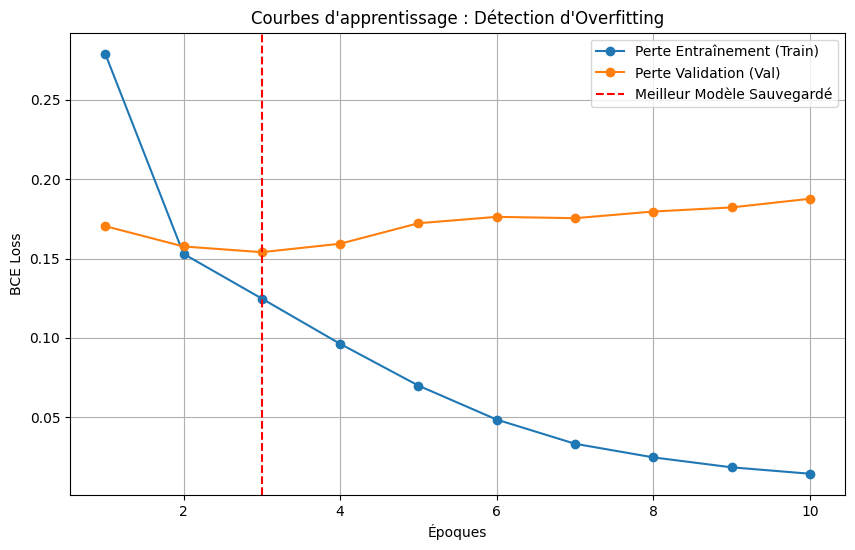

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Perte Entraînement (Train)', marker='o')
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label='Perte Validation (Val)', marker='o')

# Marquer le meilleur modèle (Époque 3)
plt.axvline(x=3, color='r', linestyle='--', label='Meilleur Modèle Sauvegardé')

plt.title('Courbes d\'apprentissage : Détection d\'Overfitting')
plt.xlabel('Époques')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# 1. Chargement du meilleur modèle
model.load_state_dict(torch.load(model_save_path))
model.eval()

# 2. Création du DataLoader de Test
test_loader = DataLoader(MedReportDataset(test_df, img_dir, transform=data_transforms),
                          batch_size=32, shuffle=False)

all_preds = []
all_targets = []

print("🧐 Évaluation du meilleur modèle sur le Test Set...")

with torch.no_grad():
    for images, targets in test_loader:
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)

        # On utilise un seuil de 0.5 pour transformer les probabilités en 0 ou 1
        preds = (outputs > 0.5).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 3. Affichage du rapport de classification
print("\n📊 RAPPORT DE CLASSIFICATION (Par Pathologie) :")
print(classification_report(all_targets, all_preds, target_names=labels, zero_division=0))

# 4. Calcul de l'AUC-ROC (Métrique standard en imagerie médicale)
auc_scores = []
for i in range(len(labels)):
    try:
        score = roc_auc_score(all_targets[:, i], all_preds[:, i])
        auc_scores.append(score)
    except ValueError:
        pass # Cas où une classe n'est pas présente dans le test set

print(f"\n📈 AUC-ROC Moyen : {np.mean(auc_scores):.4f}")

🧐 Évaluation du meilleur modèle sur le Test Set...

📊 RAPPORT DE CLASSIFICATION (Par Pathologie) :
                    precision    recall  f1-score   support

       Atelectasis       0.33      0.01      0.02        92
      Cardiomegaly       0.50      0.02      0.04        43
          Effusion       0.53      0.23      0.32       100
      Infiltration       0.50      0.08      0.14       187
              Mass       0.00      0.00      0.00        35
            Nodule       0.00      0.00      0.00        40
         Pneumonia       0.00      0.00      0.00        15
      Pneumothorax       0.00      0.00      0.00        46
     Consolidation       0.00      0.00      0.00        34
             Edema       0.00      0.00      0.00        16
         Emphysema       0.00      0.00      0.00        29
          Fibrosis       0.00      0.00      0.00        39
Pleural_Thickening       0.00      0.00      0.00        36
            Hernia       0.00      0.00      0.00         8


In [11]:
import torch.nn as nn
from torchvision import models

# On recrée une instance propre du modèle
fine_tuned_model = models.densenet121(weights='IMAGENET1K_V1')

# 1. On gèle tout par défaut
for param in fine_tuned_model.parameters():
    param.requires_grad = False

# 2. On dégèle spécifiquement le dernier bloc (DenseBlock 4) et la norme finale
# Cela permet d'adapter les filtres complexes aux textures radiologiques
for param in fine_tuned_model.features.denseblock4.parameters():
    param.requires_grad = True
for param in fine_tuned_model.features.norm5.parameters():
    param.requires_grad = True

# 3. Nouvelle tête de classification avec Dropout pour contrer l'overfitting
num_ftrs = fine_tuned_model.classifier.in_features
fine_tuned_model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4), # Augmenté à 0.4 pour plus de régularisation
    nn.Linear(512, 14),
    nn.Sigmoid()
)

fine_tuned_model = fine_tuned_model.to(device)
print("✅ Modèle prêt pour le Fine-Tuning (Couches finales dégelées)")

✅ Modèle prêt pour le Fine-Tuning (Couches finales dégelées)


In [12]:
import torch.optim as optim

# On utilise un LR très faible : 1e-5
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, fine_tuned_model.parameters()), lr=0.00001)
criterion = nn.BCELoss()

ft_history = {'train_loss': [], 'val_loss': []}
best_ft_val_loss = float('inf')
ft_model_path = os.path.join(project_root, 'models', 'fine_tuned_medreport.pth')

# Nouvelle boucle d'entraînement (5 à 10 epochs suffisent généralement)
# Nouvelle boucle d'entraînement pour le Fine-Tuning
for epoch in range(20):
    fine_tuned_model.train() # Utilise le nouveau modèle
    running_train_loss = 0.0

    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)

        optimizer_ft.zero_grad() # Utilise le nouvel optimizer (LR 1e-5)
        outputs = fine_tuned_model(images) # Utilise le nouveau modèle

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_ft.step() # Utilise le nouvel optimizer

        running_train_loss += loss.item() * images.size(0)

    avg_train_loss = running_train_loss / len(train_loader.dataset)

    # Evaluation
    fine_tuned_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = fine_tuned_model(images) # Utilise le nouveau modèle
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * images.size(0)

    avg_val_loss = running_val_loss / len(val_loader.dataset)

    ft_history['train_loss'].append(avg_train_loss)
    ft_history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/20 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Sauvegarde avec le nouveau chemin ft_model_path
    if avg_val_loss < best_ft_val_loss:
        best_ft_val_loss = avg_val_loss
        torch.save(fine_tuned_model.state_dict(), ft_model_path)
        print("⭐ Meilleur modèle Fine-Tuné sauvegardé !")

Epoch 1/20 | Train Loss: 0.5429 | Val Loss: 0.4131
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 2/20 | Train Loss: 0.3190 | Val Loss: 0.2423
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 3/20 | Train Loss: 0.2172 | Val Loss: 0.1900
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 4/20 | Train Loss: 0.1882 | Val Loss: 0.1750
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 5/20 | Train Loss: 0.1790 | Val Loss: 0.1700
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 6/20 | Train Loss: 0.1744 | Val Loss: 0.1678
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 7/20 | Train Loss: 0.1717 | Val Loss: 0.1661
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 8/20 | Train Loss: 0.1702 | Val Loss: 0.1655
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 9/20 | Train Loss: 0.1682 | Val Loss: 0.1650
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 10/20 | Train Loss: 0.1657 | Val Loss: 0.1646
⭐ Meilleur modèle Fine-Tuné sauvegardé !
Epoch 11/20 | Train Loss: 0.1643 | Val Loss: 0.1643
⭐ Meilleur modèle Fine-Tuné

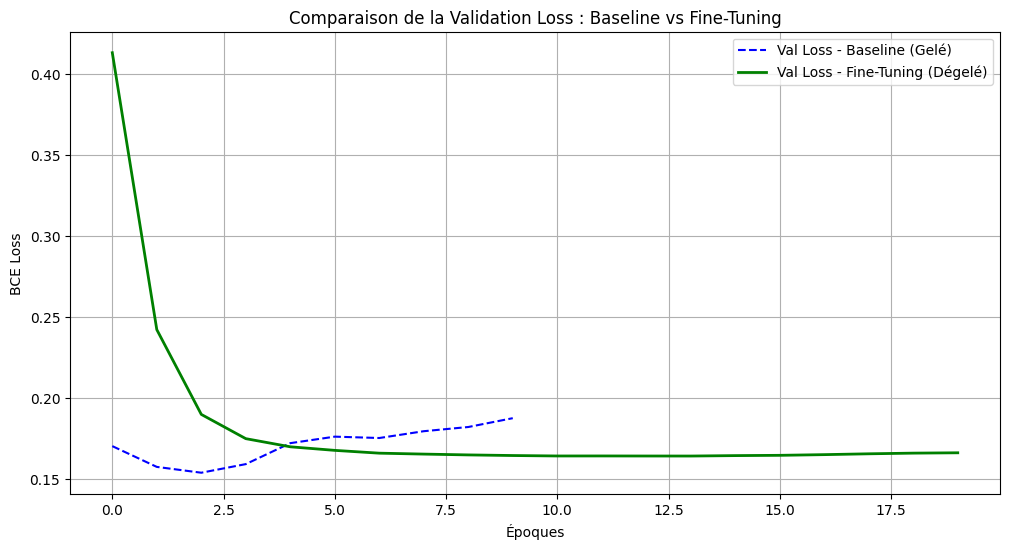

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Modèle 1 (Baseline)
plt.plot(history['val_loss'], label='Val Loss - Baseline (Gelé)', color='blue', linestyle='--')

# Modèle 2 (Fine-Tuning)
plt.plot(ft_history['val_loss'], label='Val Loss - Fine-Tuning (Dégelé)', color='green', linewidth=2)

plt.title('Comparaison de la Validation Loss : Baseline vs Fine-Tuning')
plt.xlabel('Époques')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.show()

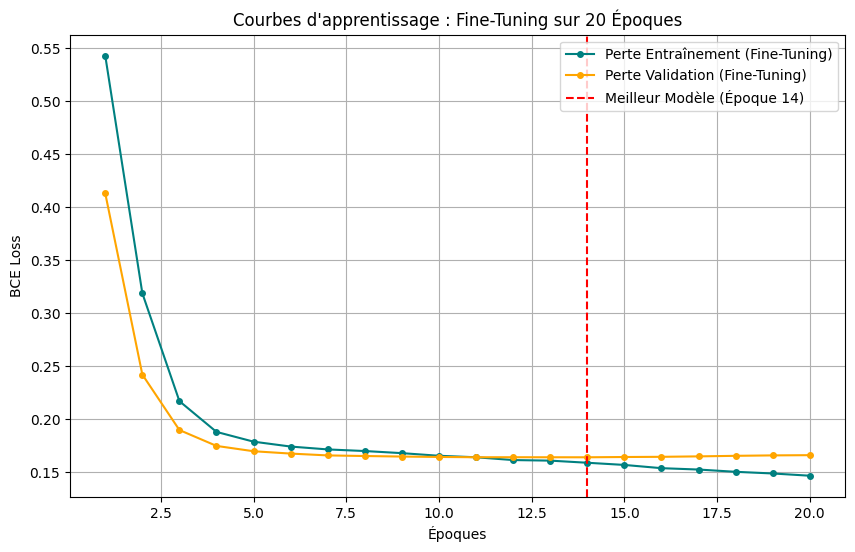

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Utilisation de ft_history pour les deux courbes
epochs_range = range(1, len(ft_history['train_loss']) + 1)

plt.plot(epochs_range, ft_history['train_loss'], label='Perte Entraînement (Fine-Tuning)', color='teal', marker='o', markersize=4)
plt.plot(epochs_range, ft_history['val_loss'], label='Perte Validation (Fine-Tuning)', color='orange', marker='o', markersize=4)

# Marquer le meilleur modèle (Époque 14 selon tes logs)
plt.axvline(x=14, color='r', linestyle='--', label='Meilleur Modèle (Époque 14)')

plt.title('Courbes d\'apprentissage : Fine-Tuning sur 20 Époques')
plt.xlabel('Époques')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# 1. Chargement du MEILLEUR modèle fine-tuné
fine_tuned_model.load_state_dict(torch.load(ft_model_path))
fine_tuned_model.eval()

all_ft_preds = []
all_targets = []

print("🧐 Évaluation du modèle Fine-Tuné sur le Test Set...")

with torch.no_grad():
    for images, targets in test_loader: # Utilise toujours le dossier local si possible
        images, targets = images.to(device), targets.to(device)
        outputs = fine_tuned_model(images)

        preds = (outputs > 0.5).cpu().numpy()
        all_ft_preds.extend(preds)
        all_targets.extend(targets.cpu().numpy())

all_ft_preds = np.array(all_ft_preds)
all_targets = np.array(all_targets)

# 2. Rapport de classification
print("\n📊 NOUVEAU RAPPORT DE CLASSIFICATION (Fine-Tuning) :")
print(classification_report(all_targets, all_ft_preds, target_names=labels, zero_division=0))

# 3. Calcul de l'AUC-ROC Global
auc_ft_scores = []
for i in range(len(labels)):
    try:
        score = roc_auc_score(all_targets[:, i], all_ft_preds[:, i])
        auc_ft_scores.append(score)
    except ValueError:
        pass

print(f"\n📈 NOUVEL AUC-ROC Moyen : {np.mean(auc_ft_scores):.4f}")

🧐 Évaluation du modèle Fine-Tuné sur le Test Set...

📊 NOUVEAU RAPPORT DE CLASSIFICATION (Fine-Tuning) :
                    precision    recall  f1-score   support

       Atelectasis       0.00      0.00      0.00        92
      Cardiomegaly       0.00      0.00      0.00        43
          Effusion       0.00      0.00      0.00       100
      Infiltration       0.00      0.00      0.00       187
              Mass       0.00      0.00      0.00        35
            Nodule       0.00      0.00      0.00        40
         Pneumonia       0.00      0.00      0.00        15
      Pneumothorax       0.00      0.00      0.00        46
     Consolidation       0.00      0.00      0.00        34
             Edema       0.00      0.00      0.00        16
         Emphysema       0.00      0.00      0.00        29
          Fibrosis       0.00      0.00      0.00        39
Pleural_Thickening       0.00      0.00      0.00        36
            Hernia       0.00      0.00      0.00     

In [17]:
print(outputs[:5]) # Regarde les valeurs réelles

tensor([[0.0493, 0.0154, 0.0227, 0.0861, 0.0177, 0.0230, 0.0053, 0.0089, 0.0153,
         0.0060, 0.0110, 0.0184, 0.0142, 0.0037],
        [0.0793, 0.0220, 0.0449, 0.1183, 0.0228, 0.0316, 0.0098, 0.0202, 0.0242,
         0.0087, 0.0206, 0.0259, 0.0258, 0.0063],
        [0.0417, 0.0162, 0.0287, 0.0597, 0.0143, 0.0210, 0.0047, 0.0103, 0.0187,
         0.0037, 0.0104, 0.0168, 0.0158, 0.0023],
        [0.0168, 0.0067, 0.0111, 0.0426, 0.0055, 0.0113, 0.0018, 0.0058, 0.0055,
         0.0028, 0.0042, 0.0090, 0.0079, 0.0011],
        [0.0771, 0.0269, 0.0587, 0.1363, 0.0459, 0.0477, 0.0118, 0.0357, 0.0315,
         0.0127, 0.0270, 0.0404, 0.0381, 0.0103]], device='cuda:0')


In [20]:
import shutil
from google.colab import files

# On zippe le dossier des modèles et les scripts pour gagner du temps
shutil.make_archive('MedReport_Backup', 'zip', '/content/MedReport-AI-Diagnostics')

# Téléchargement du zip et du notebook (.ipynb)
files.download('MedReport_Backup.zip')
# Pense aussi à faire : Fichier > Télécharger > Télécharger le .ipynb

FileNotFoundError: [Errno 2] No such file or directory: '/content/MedReport-AI-Diagnostics'